In [13]:
import numpy as np
from matplotlib import pyplot as plt
from collections import Counter
import pickle

from qiskit_qaoa.utils.gfa_utils import gfa_file_to_graph
from qiskit_qaoa.hubo.graph_to_hubo_hamiltonian import graph_to_hubo_hamiltonian
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples

In [14]:
filename = 'test_N2_W2'
copy_numbers = [1,1]

In [15]:
filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
graph, n, V, T = gfa_file_to_graph(filepath, copy_numbers)
num_qubits = n * T

full_hamiltonian = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=1.0)

def binstr(n):
    res = []
    for i in range(1 << n):
        
        # build string from bits of i
        s = ''.join('1' if (i >> j) & 1 else '0' for j in reversed(range(n)))
        res.append(s)
        
    return res

evals = evaluate_sparse_pauli_samples(binstr(num_qubits), full_hamiltonian)

Keeping constraints at times: [0]


In [16]:
def get_optimal_sv(res, atol=1e-6):
    optimal_amplitudes = [r.fun for r in res['results']]
    opt_params = res['results'][np.argmin(optimal_amplitudes)].x
    best_idx = None
    diff = 1
    for idx, x in enumerate(res['history']):
        if np.allclose(x[1], opt_params, atol=atol):
            # print(opt_params, x[1])
            if (new_diff := np.sum(np.abs(np.array(opt_params) - np.array(x[1])) ** 2)) < diff:
                best_idx = idx
                # print(best_idx, new_diff)
                diff = new_diff
    if best_idx is None:
        raise Exception('Could not find optimum; increase atol')
    print(np.round(res['history'][best_idx][1], 3))
    return res['history'][best_idx][2]
            
    

In [17]:
def plot_sv_bars(evals, sv):
    counter = Counter(evals)
    evals_set = list(set(evals))
    bars = {eval: 0 for eval in evals_set}
    for x in range(len(sv)):
        bars[evals[x]] += np.abs(sv[x]) ** 2
    sv_bars = np.array(list(bars.values()))

    random_bars = np.array([counter[eval] for eval in sorted(evals_set)]) / 2**num_qubits

    _, ax = plt.subplots(1,1,figsize=(16, 5))
    labels = evals_set
    x = np.arange(len(labels))  # the label locations
    width = 0.35  # the width of the bars

    cutoff = 20

    ax.bar(x[:cutoff] - width/2, sv_bars[:cutoff], width, label='Statevector')
    ax.bar(x[:cutoff] + width/2, random_bars[:cutoff], width, label='Random')
    ax.set_xticks(x[:cutoff])
    ax.set_xticklabels(labels[:cutoff])
    ax.set_yscale('log')
    ax.legend()

In [18]:
def plot_all_sv_bars(evals, svs, cutoff=10):
    counter = Counter(evals)
    evals_set = list(set(evals))
    svs_bars = []
    for sv in svs:
        bars = {eval: 0 for eval in evals_set}
        for x in range(len(sv)):
            bars[evals[x]] += np.abs(sv[x]) ** 2
        svs_bars.append(np.array(list(bars.values()))) 

    random_bars = np.array([counter[eval] for eval in sorted(evals_set)]) / 2**num_qubits

    # for idx in range(len(svs_bars)):
    #     print(float(svs_bars[idx][0]))
    # for idx in range(len(svs_bars)):
    #     print(float(svs_bars[idx][0]/random_bars[0]))   
    print(*[f'{float(np.round(svs_bars[idx][0], 6))},' for idx in range(len(svs_bars))])
    print(*[f'{float(np.round(svs_bars[idx][0]/random_bars[0], 3))},' for idx in range(len(svs_bars))])

    _, ax = plt.subplots(1,1,figsize=(16, 5))
    labels = evals_set
    x = np.arange(len(labels))  # the label locations
    width = 0.8/(len(svs)+1)  # the width of the bars

    for idx, sv_bars in enumerate(svs_bars):
        offset = width * (idx - (len(svs)-1)/2)
        ax.bar(x[:cutoff] + offset, sv_bars[:cutoff], width, label=f'Statevector, p = {idx + 1}')
    
    offset = width * (len(svs) - (len(svs)-1)/2)
    ax.bar(x[:cutoff] + offset, random_bars[:cutoff], width, label='Random')
    ax.set_xticks(x[:cutoff])
    ax.set_xticklabels(labels[:cutoff])
    ax.set_yscale('log')
    ax.legend()

In [19]:
filename = 'test_N2_W2'
svs = []
for p in range(1, 4):
    with open(f'/lustre/scratch127/qpg/jc59/out/qiskit/hubo_no_shot_noise_optimum/sweep.{filename}.p{p}.pkl', 'rb') as f:
        res = pickle.load(f)
        if res['best_func_val'] > 0:
            svs.append(get_optimal_sv(res))
        else:
            print([float(np.round(x, 3)) for x in res['best_params']])
            svs.append(res['best_sv'])



[2.624, -2.95]
[2.279, 0.348, -0.21, -0.18]
[2.103, 2.332, 2.766, -2.33, 0.93, -2.382]


0.116831, 0.3156, 0.417574,
3.739, 10.099, 13.362,


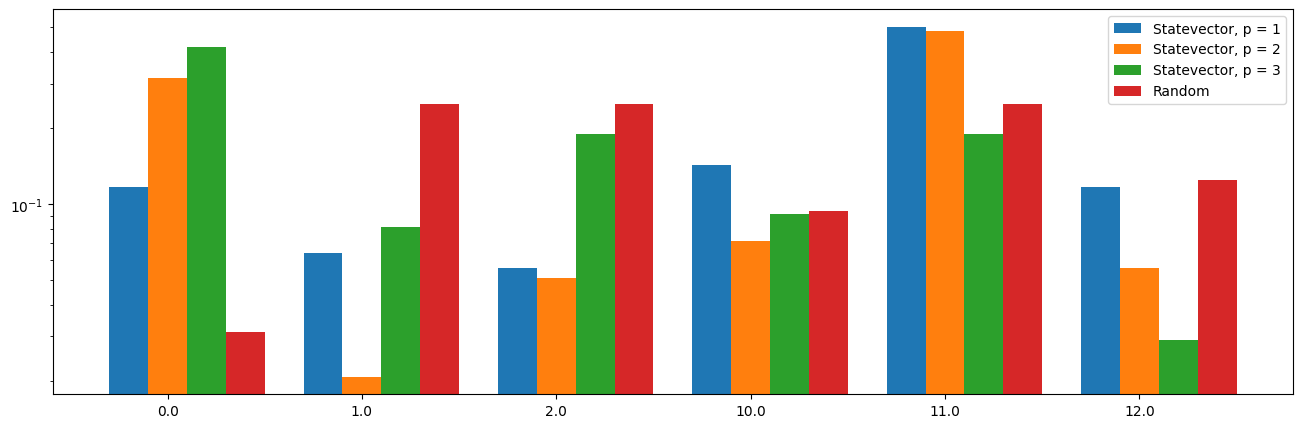

In [20]:
plot_all_sv_bars(evals, svs)

In [58]:
# p = 1
# with open(f'/lustre/scratch127/qpg/jc59/out/qiskit/hubo_no_shot_noise_optimum/sweep.{filename}.p{p}.pkl', 'rb') as f:
#     res = pickle.load(f)
# sv = get_optimal_sv(res)
# plot_sv_bars(evals, sv)

In [59]:
# best_sv = res['best_sv']

In [60]:
# p = 2
# with open(f'/lustre/scratch127/qpg/jc59/out/qiskit/hubo_no_shot_noise_optimum/sweep.{filename}.p{p}.pkl', 'rb') as f:
#     res = pickle.load(f)
# sv = get_optimal_sv(res)
# plot_sv_bars(evals, sv)

In [61]:
# best_sv = res['best_sv']

In [62]:
# p = 3
# with open(f'/lustre/scratch127/qpg/jc59/out/qiskit/hubo_no_shot_noise_optimum/sweep.{filename}.p{p}.pkl', 'rb') as f:
#     res = pickle.load(f)
# sv = get_optimal_sv(res)
# plot_sv_bars(evals, sv)

In [63]:
# p = 3
# with open(f'/lustre/scratch127/qpg/jc59/out/qiskit/hubo_no_shot_noise_optimum/single.{filename}.p{p}.pkl', 'rb') as f:
#     res = pickle.load(f)
# sv = res['history'][0][2]
# plot_sv_bars(evals, sv)

In [64]:
# with open(f'/lustre/scratch127/qpg/jc59/out/qiskit/hubo_no_shot_noise_optimum/sweep.{filename}.p1.pkl', 'rb') as f:
#     res = pickle.load(f)
# tqc = res['t_qaoa_circ']

In [65]:
# tqc.draw(fold=-1)

In [66]:

# from qiskit_aer import AerSimulator
# backend_options = dict(
#     method='unitary',
#     device='CPU',
#     precision='single',
# )
# backend = AerSimulator(**backend_options)
# backend.set_option("n_qubits", n*T)


In [67]:
# aqc1 = tqc.assign_parameters([0.4, 0.7], inplace=False)
# aqc1.save_unitary()
# aqc2 = tqc.assign_parameters([0.4+np.pi, 0.7-2*np.pi], inplace=False)
# aqc2.save_unitary()


In [68]:
# res1 = backend.run(aqc1).result()
# res2 = backend.run(aqc2).result()

In [69]:
# u1 = np.asarray(res1.results[0].data.unitary)
# u2 = np.asarray(res2.results[0].data.unitary)

In [70]:
# np.nonzero(np.abs(u1-u2) > 1e-5)

In [71]:
# p = 1
# beta_resolution, gamma_resolution = 32, 32
# while (beta_resolution ** p) * (gamma_resolution ** p) > 1000:
#     if beta_resolution == gamma_resolution:
#         beta_resolution -= 1
#     else:
#         gamma_resolution -= 1
# print(beta_resolution, gamma_resolution, (beta_resolution ** p) * (gamma_resolution ** p))

In [72]:
# p = 1
# beta_resolution, gamma_resolution = 3, 3
# while (beta_resolution ** p) * (gamma_resolution ** p) < 1000:
#     if beta_resolution < gamma_resolution:
#         beta_resolution += 1
#     else:
#         gamma_resolution += 1
# print(beta_resolution, gamma_resolution, (beta_resolution ** p) * (gamma_resolution ** p))

In [9]:
all_params = {}
for filename in ['test_N2_W2', 'trivial', 'test_N3_W4', 'test_N4_W5']:
    params = {}
    for p in range(1, 4):
        with open(f'/lustre/scratch127/qpg/jc59/out/qiskit/hubo_no_shot_noise_optimum/sweep.{filename}.p{p}.pkl', 'rb') as f:
            res = pickle.load(f)
            if res['best_func_val'] > 0:
                svs.append(get_optimal_sv(res))
            else:
                print([float(np.round(x, 3)) for x in res['best_params']])
                params[p] = list(res['best_params'])
    all_params[filename] = params

[2.624, -2.95]
[2.279, 0.348, -0.21, -0.18]
[2.103, 2.332, 2.766, -2.33, 0.93, -2.382]
[0.46, 2.934]
[2.797, 0.271, -2.936, 2.907]
[0.401, 0.339, 2.826, 2.428, 2.491, 2.674]
[0.486, 2.955]
[0.534, 0.238, 2.947, 0.462]
[0.083, 0.493, 0.265, 0.831, 2.146, 2.425]
[2.713, -2.97]
[0.519, 0.302, 2.993, -0.14]
[2.07, 0.571, 2.833, -0.216, -0.12, 0.103]


In [10]:
all_params

{'test_N2_W2': {1: [np.float64(2.623573572855404),
   np.float64(-2.950436618484883)],
  2: [np.float64(2.2786551178186687),
   np.float64(0.3484333612969359),
   np.float64(-0.20958461281251378),
   np.float64(-0.18035666937489597)],
  3: [np.float64(2.103494296555067),
   np.float64(2.331964628588021),
   np.float64(2.766077743539691),
   np.float64(-2.3298722370413767),
   np.float64(0.9304533389315034),
   np.float64(-2.3822537184722923)]},
 'trivial': {1: [np.float64(0.4604817138832364),
   np.float64(2.934248722163311)],
  2: [np.float64(2.7973874712118962),
   np.float64(0.2705232833930648),
   np.float64(-2.9358911658286457),
   np.float64(2.9068223766900205)],
  3: [np.float64(0.40121342948119815),
   np.float64(0.33932426908737173),
   np.float64(2.825988092432951),
   np.float64(2.427887017206748),
   np.float64(2.490507928475604),
   np.float64(2.6738386528394535)]},
 'test_N3_W4': {1: [np.float64(0.4864793104929956),
   np.float64(2.9554863744976756)],
  2: [np.float64(0.5